# 3. Dimensionality reduction and Clustering

This notebook documents the EDA, Dimensionality reduction and Clustering of the [OSMI Mental Health in Tech Survey 2016](https://www.kaggle.com/datasets/osmi/mental-health-in-tech-2016), according to _Task 1: Mental Health in Technology-related Jobs_ of the Unsupervised Learning and Feature Engineering course (DLBDSMLUSL01).

The written report is not part of the repository.  

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', None)

from dotenv import load_dotenv
from pathlib import Path
BASE_PATH = str(Path().cwd().parent.resolve() / "utils")
import os
import sys
sys.path.append(BASE_PATH)

from sklearn.manifold import MDS
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_samples, silhouette_score, adjusted_rand_score
from sklearn.preprocessing import OrdinalEncoder

from skbio.stats.distance import DistanceMatrix, mantel

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association
from scipy.spatial.distance import squareform, is_valid_dm

from statsmodels.stats.multitest import multipletests

from itertools import combinations

# This function is in this repository
from metrics import gower_matrix

In [2]:
load_dotenv(Path().cwd().parent.joinpath(".env"))

True

In [3]:
# Dataset location
LOCATION_DATSET = Path(os.getenv("LOCATION_DATASET")).parent

In [4]:
df = pd.read_csv(LOCATION_DATSET.joinpath("osmi_mental_health_clean.csv"), index_col=0)

In [5]:
#Verify no NaN values are in the dataset
df.isna().sum().sum()

np.int64(0)

In [6]:
DATA_UTILS = Path(os.getenv("DATA_UTILS"))

## EDA

In [7]:
n_samples, n_columns = df.shape

- 81% of surveyed worked wor for a company
- 19% are self-employed
- Age range is between 17 and 55 years old, with a mean of 33.6 years old. TODO: Test for statistical difference?
- Around 40% of surveyed worker currently have a mental health disorder.
- 50% of workers have been diagnosed before with a mental health disorder by a medical professional
- Almost 60% have seeked help -> High awareness in the population is likely
- Tech industry still has a majority of male workers
- Around 65% of female workers have been diagnosed with a mental health disorder in the past in contrast to 44% amongst the male workers. Among non.binary workers, 77% of them have been diagnosed in past.
- Female and non-binary workers have seeked help of a health professional before with 75% and 88% respectively, in contrast only 52% of men have done so

In [8]:
df["What is your age?"].describe()

count    1413.000000
mean       33.630573
std         7.289208
min        17.000000
25%        28.000000
50%        33.000000
75%        38.000000
max        55.000000
Name: What is your age?, dtype: float64

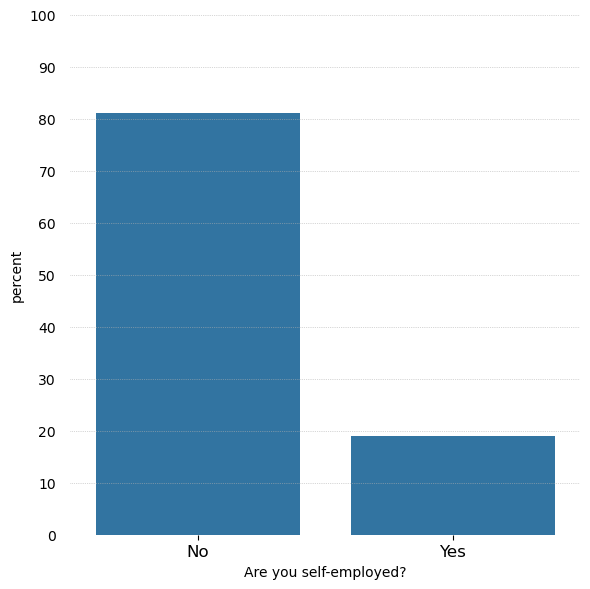

In [9]:
# How many people are self-employed
fig, ax = plt.subplots(figsize=(6,6), nrows=1, ncols=1)
sns.countplot(data=df, x="Are you self-employed?", stat="percent", ax=ax)
ax.set_xticks([0,1])
ax.set_yticks(np.arange(0,110,10))
ax.set_ylim([0,100])
ax.set_xticklabels(["No", "Yes"], fontsize=12)
ax.grid(True, linewidth=0.5, linestyle=":", axis="y")
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.tick_params(axis="y", length=0, pad=10)
fig.tight_layout()

In [10]:
df[["What is your gender?", "What is your age?"]].groupby("What is your gender?").describe()

What is your age?                                         \
                                 count       mean       std   min   25%   50%   
What is your gender?                                                            
female                           336.0  33.720238  8.059425  19.0  27.0  32.0   
male                            1042.0  33.730326  7.037106  17.0  29.0  33.0   
non-binary                        35.0  29.800000  5.905132  20.0  26.0  30.0   

                                  
                       75%   max  
What is your gender?              
female                38.0  55.0  
male                  38.0  55.0  
non-binary            33.0  46.0

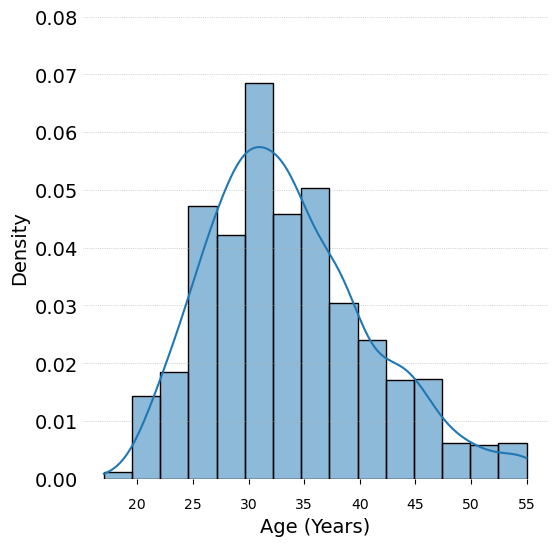

In [11]:
fig, ax = plt.subplots(figsize=(6,6), nrows=1, ncols=1)
sns.histplot(df, x ="What is your age?", bins=15, kde=True, stat="density", alpha=0.5, ax=ax)

ax.grid(True, linewidth=0.5, linestyle=':', axis="y")
ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)
ax.set_xlabel("Age (Years)", fontsize=14)
ax.set_ylabel(ax.get_ylabel(), fontsize=14)
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", pad=10)

In [12]:
df_explore = df.copy()

In [13]:
encoder = OrdinalEncoder(categories=[["No", "Yes", "Maybe"]])
df_explore["Do you currently have a mental health disorder?"] = encoder.fit_transform(df_explore[["Do you currently have a mental health disorder?"]]).astype(np.int64)

df_explore["Have you been diagnosed with a mental health condition by a medical professional?"] = encoder.transform(df_explore[["Have you been diagnosed with a mental health condition by a medical professional?"]].values).astype(np.int64)

/Users/jorgetellez/opt/anaconda3/envs/unsup/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(


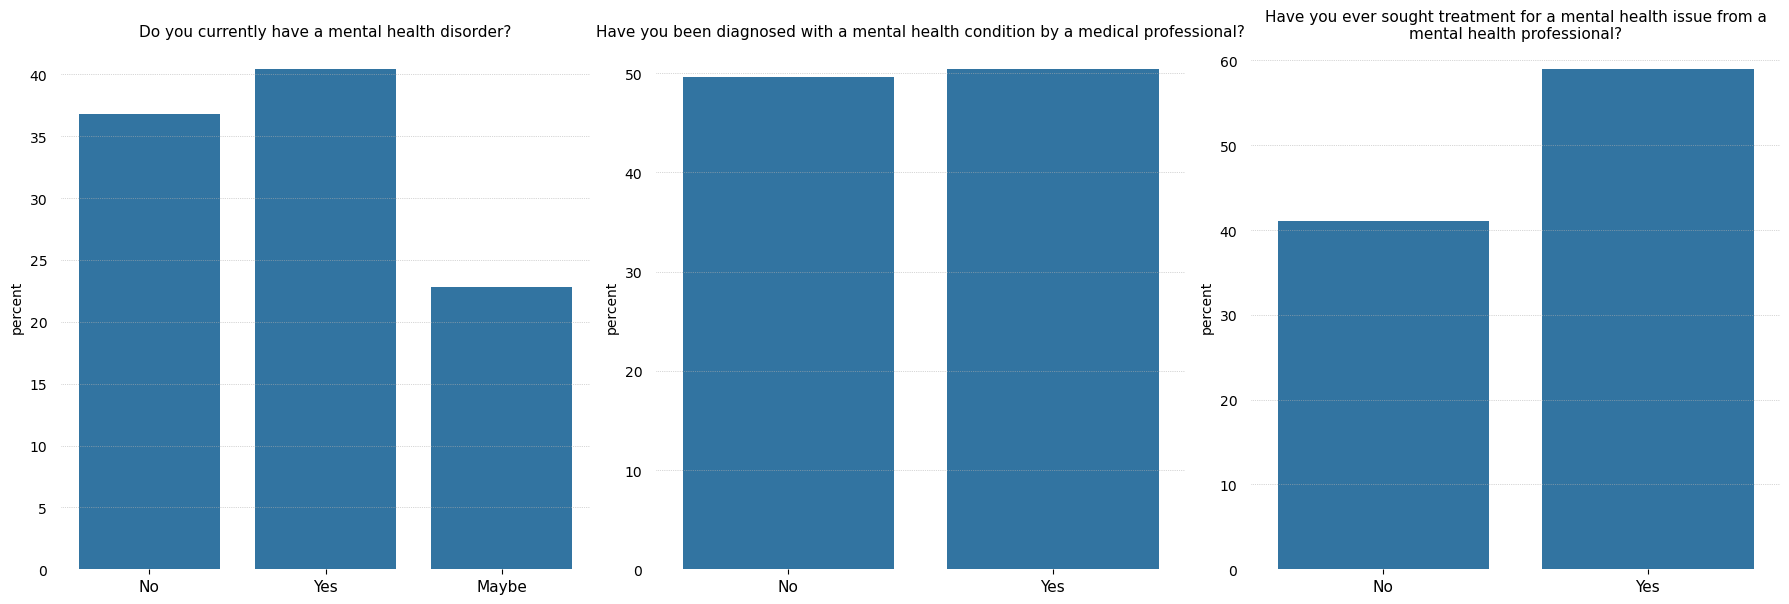

In [14]:
fig, axs = plt.subplots(figsize=(18,6), nrows=1, ncols=3)
sns.countplot(df_explore, x="Do you currently have a mental health disorder?", stat="percent", ax=axs[0])
axs[0].set_xticks([0,1, 2])
axs[0].set_xticklabels(["No", "Yes", "Maybe"], fontsize=11)
sns.countplot(df_explore, x="Have you been diagnosed with a mental health condition by a medical professional?", stat="percent", ax=axs[1])
axs[1].set_xticks([0,1])
axs[1].set_xticklabels(["No", "Yes"], fontsize=11)
sns.countplot(df_explore, x="Have you ever sought treatment for a mental health issue from a mental health professional?", stat="percent", ax=axs[2])
axs[2].set_xticks([0,1])
axs[2].set_xticklabels(["No", "Yes"], fontsize=11)

for ax in axs:
    ax.set_title(f"{ax.get_xlabel()}", wrap=True, fontsize=11)
    ax.grid(True, linewidth=0.5, linestyle=":", axis="y")
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    ax.tick_params(axis="y", length=0, pad=10)
    ax.set_xlabel(None)
fig.tight_layout()

In [15]:
gender_count = df["What is your gender?"].value_counts()
gender_count

What is your gender?
male          1042
female         336
non-binary      35
Name: count, dtype: int64

In [16]:
diagnosed_by_gender = (
    df_explore
    .groupby("What is your gender?")
    ["Have you been diagnosed with a mental health condition by a medical professional?"]
    .mean()
)
diagnosed_by_gender

What is your gender?
female        0.651786
male          0.447217
non-binary    0.771429
Name: Have you been diagnosed with a mental health condition by a medical professional?, dtype: float64

In [17]:
seeked_help_by_gender = (
    df_explore
    .groupby("What is your gender?")
    ["Have you ever sought treatment for a mental health issue from a mental health professional?"]
    .mean()
)
seeked_help_by_gender

What is your gender?
female        0.750000
male          0.527831
non-binary    0.885714
Name: Have you ever sought treatment for a mental health issue from a mental health professional?, dtype: float64

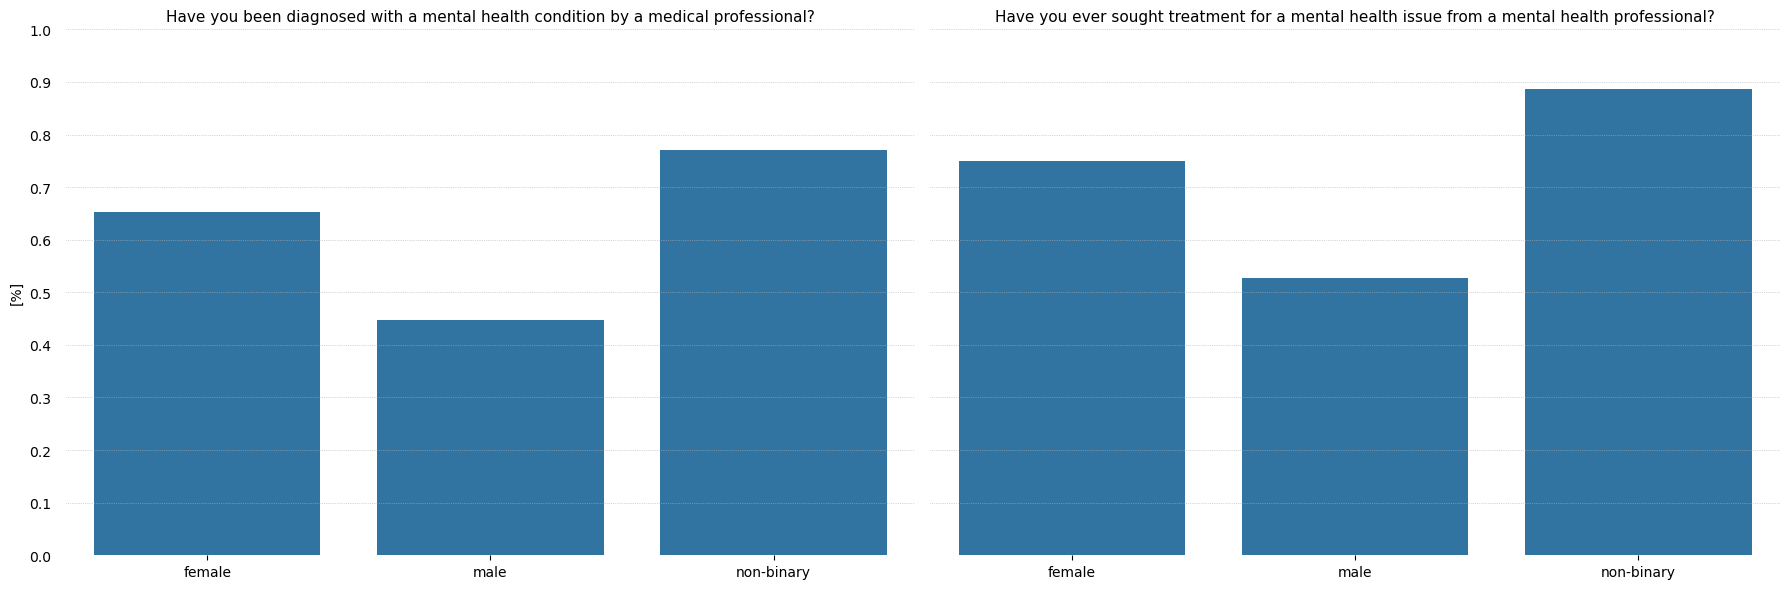

In [18]:
fig, axs = plt.subplots(figsize=(18,6), nrows=1, ncols=2, sharey=True)
question_1 = "Have you been diagnosed with a mental health condition by a medical professional?"
question_2 = "Have you ever sought treatment for a mental health issue from a mental health professional?"

sns.barplot(diagnosed_by_gender.reset_index(), x="What is your gender?", y=question_1, ax=axs[0])
axs[0].set_title(f"{question_1}", wrap=True, fontsize=11)
sns.barplot(seeked_help_by_gender.reset_index(), x="What is your gender?", y=question_2, ax=axs[1])
axs[1].set_title(f"{question_2}", wrap=True, fontsize=11)

for ax in axs:
    ax.grid(True, linewidth=0.5, linestyle=":", axis="y")
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    ax.tick_params(axis="y", length=0, pad=10)
    ax.set_xlabel(None)
    ax.set_yticks(np.arange(0,1.1,.1))
    ax.set_ylabel("[%]")
fig.tight_layout()

In [19]:
roles = df["Which of the following best describes your work position?"].value_counts()
roles = (roles / roles.sum())*100

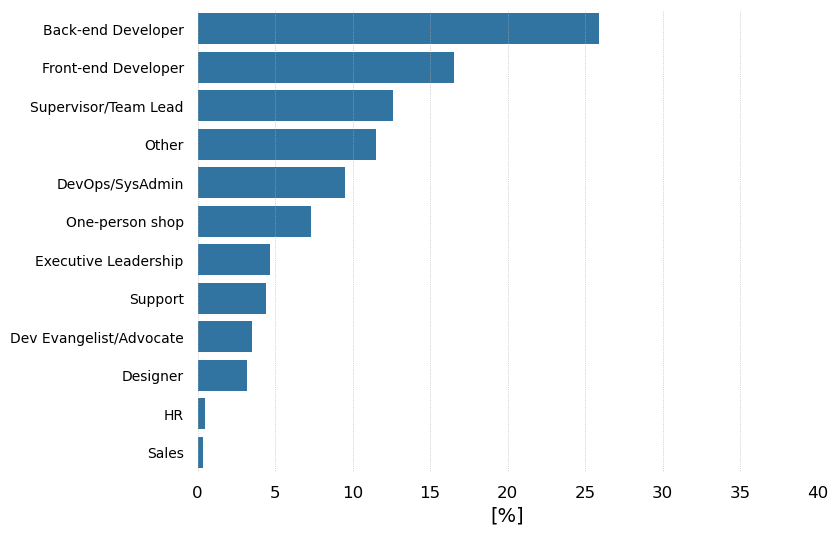

In [20]:
fig, ax = plt.subplots(figsize=(8,6))
sns.barplot(roles, orient="h", ax=ax)
ax.grid(True, linewidth=0.5, linestyle=":", axis="x")
ax.set_xticks(np.arange(0,45,5))
ax.set_xticklabels(ax.get_xticks(), fontsize=12)
ax.set_ylabel(None)
ax.set_xlabel("[%]", fontsize=14)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.tick_params(axis="both", length=0, pad=10)

In [21]:
encoder = OrdinalEncoder(categories=[["Never", "Sometimes", "Always"]])
df_explore["Do you work remotely?"] = encoder.fit_transform(df_explore[["Do you work remotely?"]]).astype(np.int64)

Text(0, 0.5, '[%]')

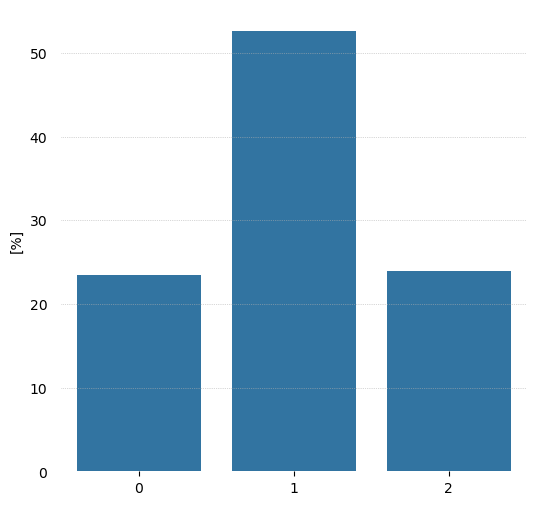

In [22]:
fig, ax = plt.subplots(figsize=(6,6))
sns.countplot(df_explore, x="Do you work remotely?", stat="percent", ax=ax)

ax.grid(True, linewidth=0.5, linestyle=":", axis="y")
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.tick_params(axis="y", length=0, pad=10)
ax.set_xlabel(None)
ax.set_ylabel("[%]")

In [23]:
willing_toshare_mental_issue = df[df["Do you think that discussing a mental health disorder with your employer would have negative consequences?"]!= "Not applicable"]
n_samples, _ = willing_toshare_mental_issue.shape
print(n_samples)
willing_toshare_mental_issue["Do you think that discussing a mental health disorder with your employer would have negative consequences?"].value_counts() / n_samples

1146


Do you think that discussing a mental health disorder with your employer would have negative consequences?
Maybe    0.424956
No       0.382199
Yes      0.192845
Name: count, dtype: float64

In [24]:
willing_to_share_physical_issue = df[df["Do you think that discussing a physical health issue with your employer would have negative consequences?"]!= "Not applicable"]
n_samples, _ = willing_to_share_physical_issue.shape
print(n_samples)
willing_to_share_physical_issue["Do you think that discussing a physical health issue with your employer would have negative consequences?"].value_counts() / n_samples

1146


Do you think that discussing a physical health issue with your employer would have negative consequences?
No       0.730366
Maybe    0.233857
Yes      0.035777
Name: count, dtype: float64

## Feature selection

Pairwise $\chi^2$ tests and _Cramer's V_ statistic were used to identify highly associated features.  
As observed during the data cleaning, the missing values are not at random, they were driven by the survey design, e.g., questions conditional on _current_ or _previous_ employment.

The high values of Cramer's V in many cases, confirmed that the missingness carries meaningful information, for this reason, automatic feature selection based on the $\chi^2$ test results is avoided.  
Instead, features with high redundancy / strong association are reviewed and removed manually.

In [25]:
categorical_columns = [col for col in df.columns if col != "What is your age?"]
results = []
for col1, col2 in combinations(categorical_columns, 2):
    table = pd.crosstab(df[col1], df[col2])
    chi2, pvalue, _, _ = chi2_contingency(table)
    v = association(table, method="cramer")
    result = {
        "feature1" : col1,
        "feature2" : col2,
        "chi2" : chi2,
        "pvalue" : pvalue,
        "cramers_v" : v
    }
    results.append(result)

In [26]:
results_df = pd.DataFrame(results).sort_values(by="cramers_v", ascending=False)
results_df

,feature1,feature2,chi2,pvalue,cramers_v
529,Do you have previous employers?,Was your anonymity protected if you chose to t...,1413.000000,1.048757e-304,1.000000
528,Do you have previous employers?,Did your previous employers provide resources ...,1413.000000,4.449044e-306,1.000000
527,Do you have previous employers?,Did your previous employers ever formally disc...,1413.000000,1.048757e-304,1.000000
4,Are you self-employed?,Has your employer ever formally discussed ment...,1413.000000,4.449044e-306,1.000000
5,Are you self-employed?,Does your employer offer resources to learn mo...,1413.000000,4.449044e-306,1.000000
...,...,...,...,...,...
227,Has your employer ever formally discussed ment...,Do you have a family history of mental illness?,1.722093,9.434029e-01,0.024686
465,Would you feel comfortable discussing a mental...,What is your gender?,1.552680,9.559187e-01,0.023440
537,Do you have previous employers?,Would you bring up a mental health issue with ...,0.394192,8.211117e-01,0.016703
32,Are you self-employed?,Do you have a family history of mental illness?,0.380661,8.266860e-01,0.016413


In [27]:
redundant = results_df[results_df["cramers_v"] > 0.5][["feature1", "feature2", "cramers_v"]]
for i, s in redundant.iterrows():
    print(s["feature1"], "--", s["feature2"])
    print()

Do you have previous employers? -- Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?

Do you have previous employers? -- Did your previous employers provide resources to learn more about mental health issues and how to seek help?

Do you have previous employers? -- Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?

Are you self-employed? -- Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?

Are you self-employed? -- Does your employer offer resources to learn more about mental health concerns and options for seeking help?

Are you self-employed? -- Do you think that discussing a physical health issue with your employer would have negative consequences?

Do you have previous employers? -- Do you think that discussing a physical health 

## Gower Distance

To be able to apply Dimensionality Reduction techniques to the data to get a better sense of it and be able to visualize it, the observations need to be transformed into distance metrics.  
The dataset includes mix data type: numeric, nominal and ordinal, to deal with this we use the Gower distance.

As a didactic exercise, the calculation of the Gower matrix has been implemented from scratch using numpy.  
Once the distance matrix has been calculated the data will be visualized using _Multidimensional Scaling_.

The idea of _Gower's distance_ is to measure how similar (or dissimilar) two observations are when the dataset contains _mixed types of variables_, such as numeric, ordinal, and categorical features.  
Gower's distance calculates a similarity score that is feature-specific and then combines the score for each feature into a single measure.

- __Numeric variables and ordinal variables__  
  The similarity between two observations is based on the absolute difference between the values of the observations for the respective feature, normalized by the range of the variable.

- __Nominal categorical variables__
  The similarity is __1__ if if both observations belong to the same category and __0__ if they belong to different categories.

The overall distance between the $i$ and $j$ observations is given by:

$$
\mathbf{D_{ij}} = 1 - \mathbf{S_{ij}}
$$

Where:  

- $\mathbf{S_{ij}}$ represents the overall similarity score between the observations $i$ and $j$ in the dataset.

The similarity score $\mathbf{S_{ij}}$ is calculated as:

$$
\mathbf{S_{ij}} = \frac{\sum_{k=1}^{p}( w_{ijk} \cdot s_{ijk})}{\sum_{k=1}^{p} w_{ijk}}
$$

Where:  

- $i$ and $j$ refer to the $i^{th}$ and $j^{th}$ observations in the dataset.
- $k$ refers to the index of the feature (the column in the dataset). 
- $s_{ijk}$ refers to the similarity score for the $i^{th}$ and $j^{th}$ observations, which is calculated depending on the data type of the feature $k$.  
- $w_{ijk}$ refers to the weight assigned to the similarity score. $w_{ijk} = 1$ for the features that can be compared and $w_{ijk} = 0$ for the ones that cannot be compared.

Missing values are handled automatically in this formulation, if one of both observations have a missing value for a feature $k$, they cannot be compared so the weight $w_{ijk} = 0$.

### Calculation of the similarity scores

1. For numerical and ordinal variables

$$
s_{ijk} = 1 - \frac{|x_{ik} - x_{jk}|}{max(x_k) - min(x_k)}
$$

2. For nominal variables

$$
s_{ijk} =
\begin{cases}
1, & \text{if } x_{ik} = x_{jk} \\
0, & \text{if } x_{ik} \neq x_{jk}
\end{cases}
$$

### Notes

In the implementation presented here, the edge case where one or more rows contain all NaN values, the returned matrix will show 1's for the corresponding row and column.

In [28]:
to_drop = [
    'Are you self-employed?',
    'Do you have previous employers?',
    'Have you had a mental health disorder in the past?',
    'Would you have been willing to discuss a mental health issue with your previous co-workers?',
    'Would you feel comfortable discussing a mental health disorder with your coworkers?',
    'Did your previous employers provide resources to learn more about mental health issues and how to seek help?',
    'Does your employer provide mental health benefits as part of healthcare coverage?',
    'Does your employer offer resources to learn more about mental health concerns and options for seeking help?',
    'Were you aware of the options for mental health care provided by your previous employers?',
    'Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?'
]

In [29]:
df_reduced = df.drop(to_drop, axis=1)
df_reduced.shape

(1413, 34)

In [30]:
nominal_cols = [
    'Are you self-employed?',
    'How many employees does your company or organization have?',
    'Is your employer primarily a tech company/organization?',
    'Does your employer provide mental health benefits as part of healthcare coverage?',
    'Do you know the options for mental health care available under your employer-provided coverage?',
    'Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?',
    'Does your employer offer resources to learn more about mental health concerns and options for seeking help?',
    'Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?',
    'Do you think that discussing a mental health disorder with your employer would have negative consequences?',
    'Do you think that discussing a physical health issue with your employer would have negative consequences?',
    'Would you feel comfortable discussing a mental health disorder with your coworkers?',
    'Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?',
    'Do you feel that your employer takes mental health as seriously as physical health?',
    'Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?',
    'Do you have previous employers?',
    'If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:',
    'Have your previous employers provided mental health benefits?',
    'Were you aware of the options for mental health care provided by your previous employers?',
    'Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?',
    'Did your previous employers provide resources to learn more about mental health issues and how to seek help?',
    'Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?',
    'Do you think that discussing a mental health disorder with previous employers would have negative consequences?',
    'Do you think that discussing a physical health issue with previous employers would have negative consequences?',
    'Would you have been willing to discuss a mental health issue with your previous co-workers?',
    'Would you have been willing to discuss a mental health issue with your direct supervisor(s)?',
    'Did you feel that your previous employers took mental health as seriously as physical health?',
    'Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?',
    'Would you be willing to bring up a physical health issue with a potential employer in an interview?',
    'Would you bring up a mental health issue with a potential employer in an interview?',
    'How willing would you be to share with friends and family that you have a mental illness?',
    'Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?',
    'Do you have a family history of mental illness?',
    'Have you had a mental health disorder in the past?',
    'Do you currently have a mental health disorder?',
    'Have you been diagnosed with a mental health condition by a medical professional?',
    'Have you ever sought treatment for a mental health issue from a mental health professional?',
    'If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?',
    'If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?',
    'Which of the following best describes your work position?',
    'What is your gender?'
]

ordinal_cols = {
    'Do you feel that being identified as a person with a mental health issue would hurt your career?' : ['No, it has not', "No, I don't think it would", 'Maybe', 'Yes, I think it would', 'Yes, it has'],
    'Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?' : ['No, they do not', "No, I don't think they would", 'Maybe','Yes, I think they would','Yes, they do'],
    'Do you work remotely?' : ['Never', 'Sometimes', 'Always']
}

numerical_cols = ['What is your age?']

In [31]:
len(nominal_cols) + len(ordinal_cols) + len(numerical_cols)

44

As mentioned above, in the _Feature selection_ section, the missing answers in the dataset represent structure and are not Missing At Random.  
Two alternatives are explored here:

1. Calculation of the distance matrix and Non-Metric MDS using all features, i.e., 44 questions of the dataset.
2. Calculation of the distance matrix and Non-Metric MDS using a reduced number of features, in this case 34 features after manual feature selection.

### All questions included

In [32]:
D = gower_matrix(
    df,
    nominal_cols=nominal_cols,
    ordinal_cols=ordinal_cols,
    numerical_cols=numerical_cols,
    as_frame=True
)

In [33]:
is_valid_dm(D)

True

In [ ]:
mds = MDS(
    n_components=2,
    metric_mds=False,
    n_init=10,
    max_iter=500,
    metric="precomputed",
    init="random",
)

In [ ]:
D_transformed = mds.fit_transform(D)

In [ ]:
D_transformed

In [ ]:
# Store the transformed data
pd.DataFrame(D_transformed, columns=["feature1", "feature2"]).to_csv(DATA_UTILS.joinpath("NMDS_full.csv"), sep=";", index=False)

In [34]:
# Load the NMDS using all features 
# Running NMDS takes long time so a copy of the reduced dataset has been stored
D_transformed = pd.read_csv(DATA_UTILS.joinpath("NMDS_full.csv"), sep=";").values

In [35]:
D_transformed

array([[ 0.14143929, -0.21343889],
       [ 0.25386607,  0.48673711],
       [ 0.07206256, -0.39035563],
       ...,
       [-0.11507064,  0.66567404],
       [-0.20310104,  0.07216626],
       [ 0.91754782,  0.28902466]], shape=(1413, 2))

### After manual feature selection

In [36]:
D_reduced = gower_matrix(
    df_reduced,
    nominal_cols=nominal_cols,
    ordinal_cols=ordinal_cols,
    numerical_cols=numerical_cols,
    as_frame=True
)

In [37]:
is_valid_dm(D_reduced)

True

In [ ]:
mds_reduced = MDS(
    n_components=2,
    metric_mds=False,
    n_init=10,
    max_iter=500,
    metric="precomputed",
    init="random"
)

In [ ]:
D_transformed_reduced = mds_reduced.fit_transform(D_reduced)

In [ ]:
D_transformed_reduced

In [ ]:
pd.DataFrame(D_transformed_reduced, columns=["feature1", "feature2"]).to_csv(DATA_UTILS.joinpath("NMDS_reduced.csv"), sep=";", index=False)

In [38]:
# Load the NMDS using all features 
# Running NMDS takes long time so a copy of the reduced dataset has been stored
D_transformed_reduced = pd.read_csv(DATA_UTILS.joinpath("NMDS_reduced.csv"), sep=";").values

In [39]:
D_transformed_reduced

array([[-0.34841639,  0.20781179],
       [-0.31893282, -0.41811664],
       [-0.08376952,  0.40954944],
       ...,
       [ 0.41788239, -0.42827393],
       [ 0.14535322, -0.39257303],
       [-0.84206418, -0.13187012]], shape=(1413, 2))

## 4. Visualization

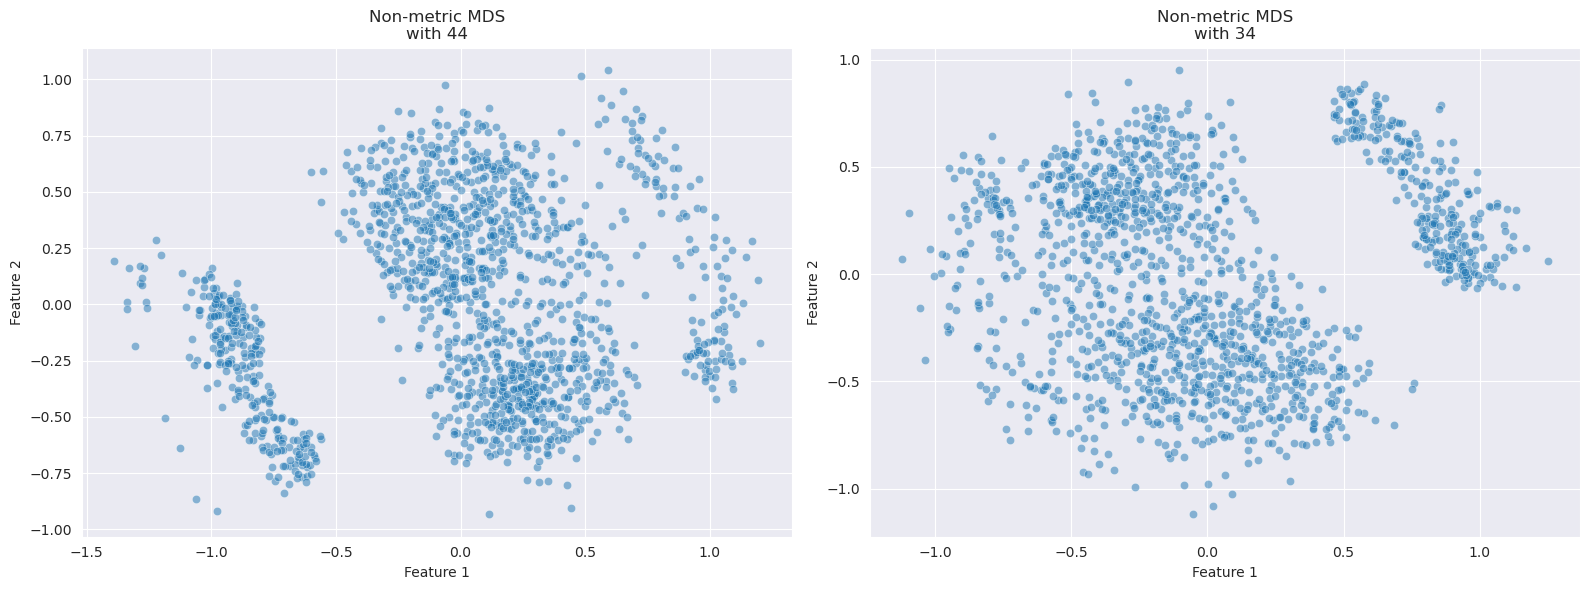

In [40]:
_, n_features = df.shape
_, n_features_reduced = df_reduced.shape

with sns.axes_style("darkgrid"):
    fig, axs = plt.subplots(figsize=(16,6), nrows=1, ncols=2)

    sns.scatterplot(x=D_transformed[:,0],
                    y=D_transformed[:,1],
                    alpha=0.5,
                    ax=axs[0])
    axs[0].set_title(f"Non-metric MDS\nwith {n_features}")
    
    sns.scatterplot(x=D_transformed_reduced[:,0],
                    y=D_transformed_reduced[:,1],
                    alpha=0.5,
                    ax=axs[1])
    axs[1].set_title(f"Non-metric MDS\nwith {n_features_reduced}")
    
    for ax in axs:
        ax.set_xlabel(r"Feature 1")
        ax.set_ylabel(r"Feature 2")
        
fig.tight_layout()    

In [41]:
def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_,
         model.distances_,
         counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

### Mantel test

To assess whether the manual feature selection altered the structure of the data, a Mantel test is performed between _D_ and _D_reduced_.  

The _Mantel_ test compares two distance matrices (in this case _D_ and _D_reduced_) by calculating the correlation between the distances in the lower or open triangular portions of the matrices.
The test calculates the $r_M$ statistic given two distances matrices:

$$
r_{M} = \frac{1}{d-1} \sum_{i=1}^{n-1} \sum_{j=i+1}^{n} \text{stand}(D_X)_{ij} \text{ stand}(D_Y)_{ij}
$$

where:

$$
d = \frac{n(n-1)}{2}
$$

where:

- $n$ is the number of rows/columns of each of the distance matrices.
- $\text{stand}(D_X)_{ij} \text{ stand}(D_Y)_{ij}$ are the distance matrices with ther _upper triangules_ containing the standardized distances.

Mantel tests:

_Null hypothesis_ $H_0$ that there is no linear correlation between the two distance matrices. 
_Alternative hypothesis_ $H_a$: There distance matrices are lineraly correlated.

In [42]:
gower = DistanceMatrix(D)

gower_reduced = DistanceMatrix(D_reduced)

r, pvalue, n = mantel(
    gower,
    gower_reduced,
    method="pearson"
)

In [43]:
r

np.float64(0.9611083461749119)

In [44]:
pvalue

np.float64(0.001)

### Clusters

In [45]:
model_complete = AgglomerativeClustering(
    n_clusters=3,
    metric="precomputed",
    linkage="complete",
    compute_full_tree=True,
    distance_threshold=None,
    compute_distances=True
).fit(D)

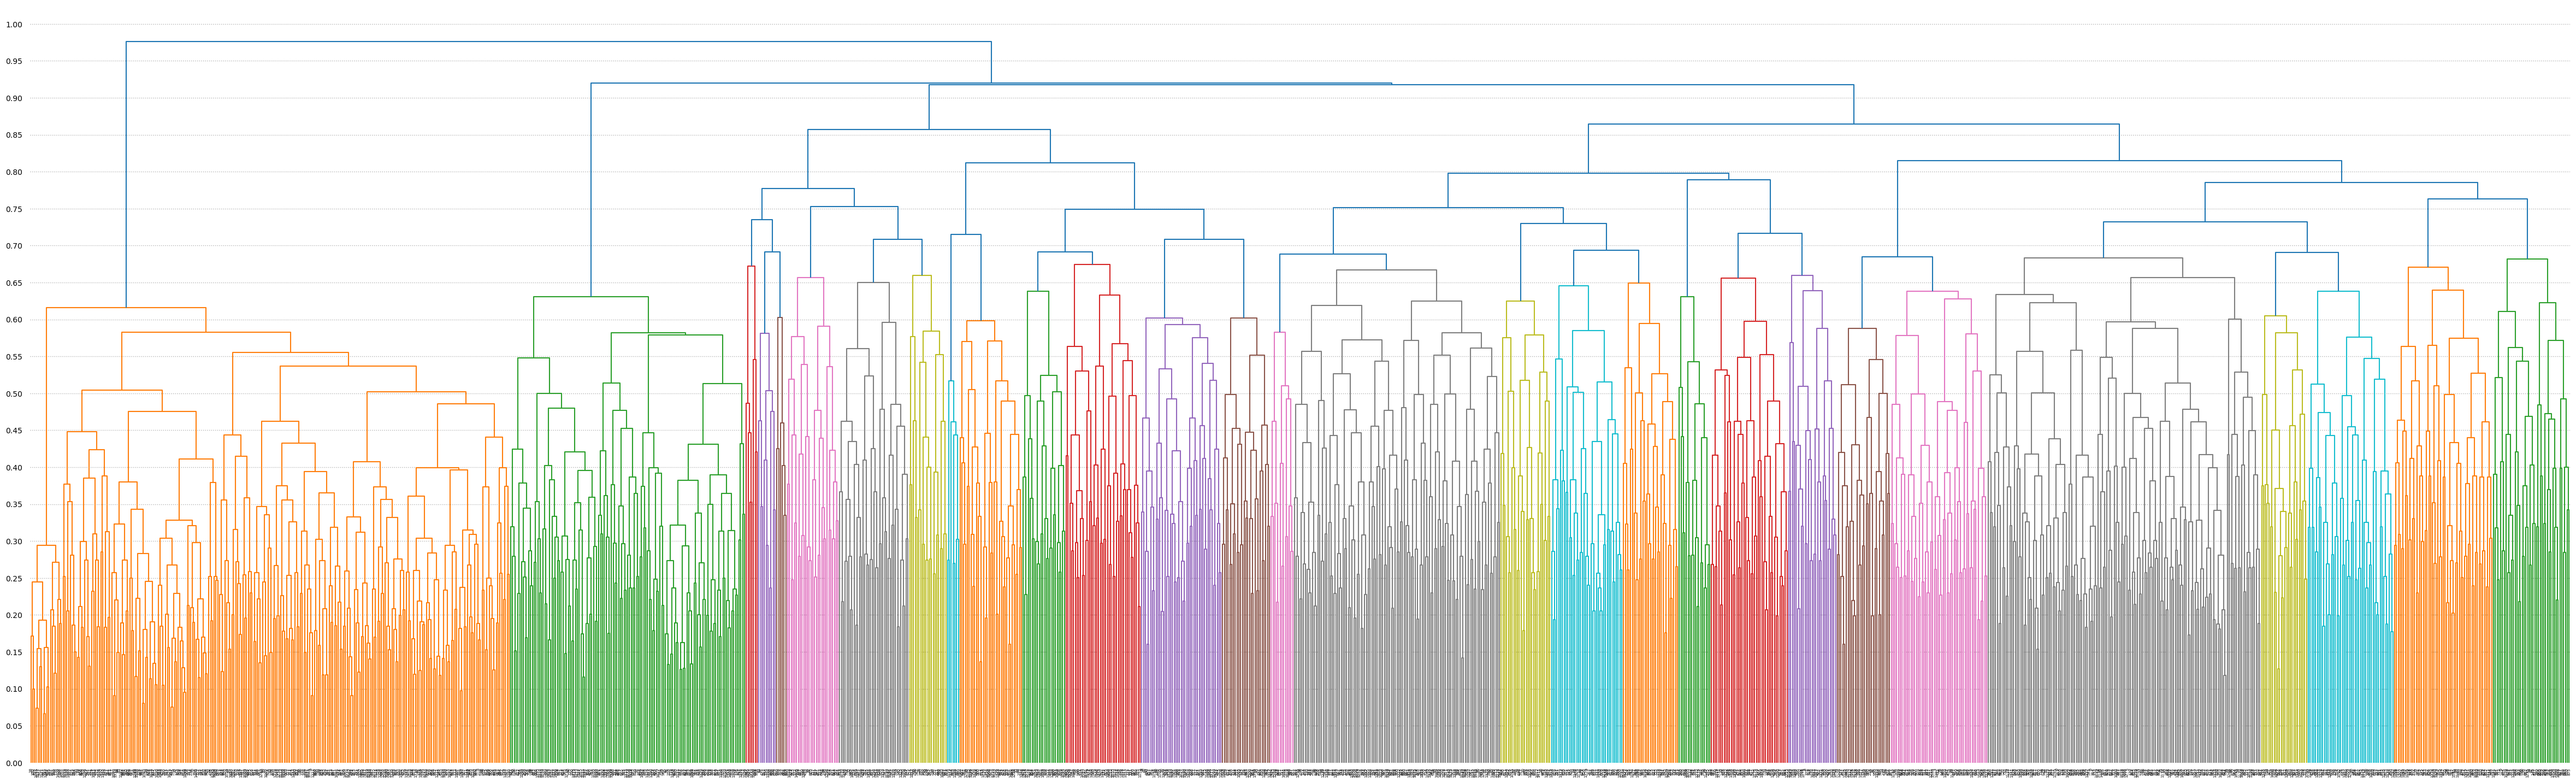

In [46]:
fig, ax = plt.subplots(figsize=(60,18))
ax.grid(True, linewidth=1, linestyle=":", axis="y")
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.tick_params(axis="y", length=0, pad=10)
ax.set_yticks(np.arange(0,1.1,.05))
plot_dendrogram(model_complete, ax=ax)

In [47]:
model_complete_reduced = AgglomerativeClustering(
    n_clusters=3,
    metric="precomputed",
    linkage="complete",
    compute_full_tree=True,
    distance_threshold=None,
    compute_distances=True
).fit(D_reduced)

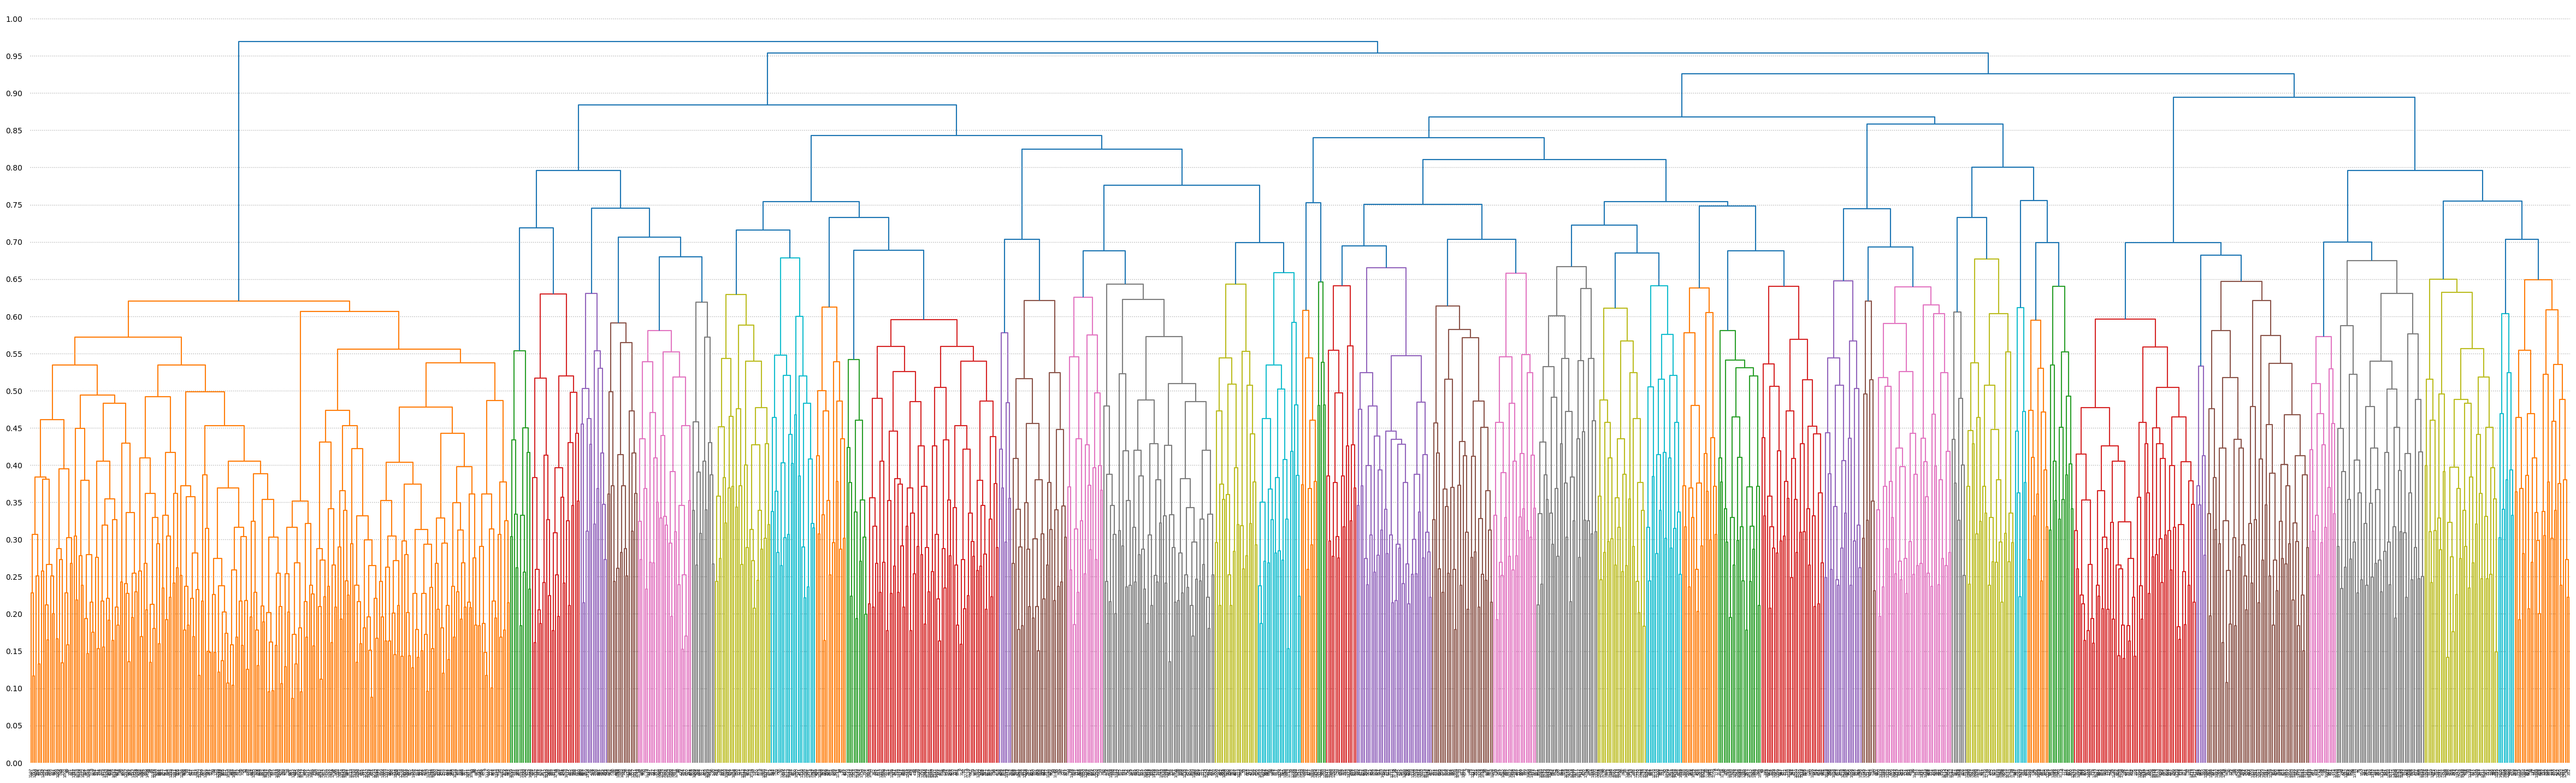

In [48]:
fig, ax = plt.subplots(figsize=(60,18))
ax.grid(True, linewidth=1, linestyle=":", axis="y")
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.tick_params(axis="y", length=0, pad=10)
ax.set_yticks(np.arange(0,1.1,.05))
plot_dendrogram(model_complete_reduced, ax=ax)

In [49]:
model_average = AgglomerativeClustering(
    n_clusters=3,
    metric="precomputed",
    linkage="average",
    compute_full_tree=True,
    distance_threshold=None,
    compute_distances=True
).fit(D)

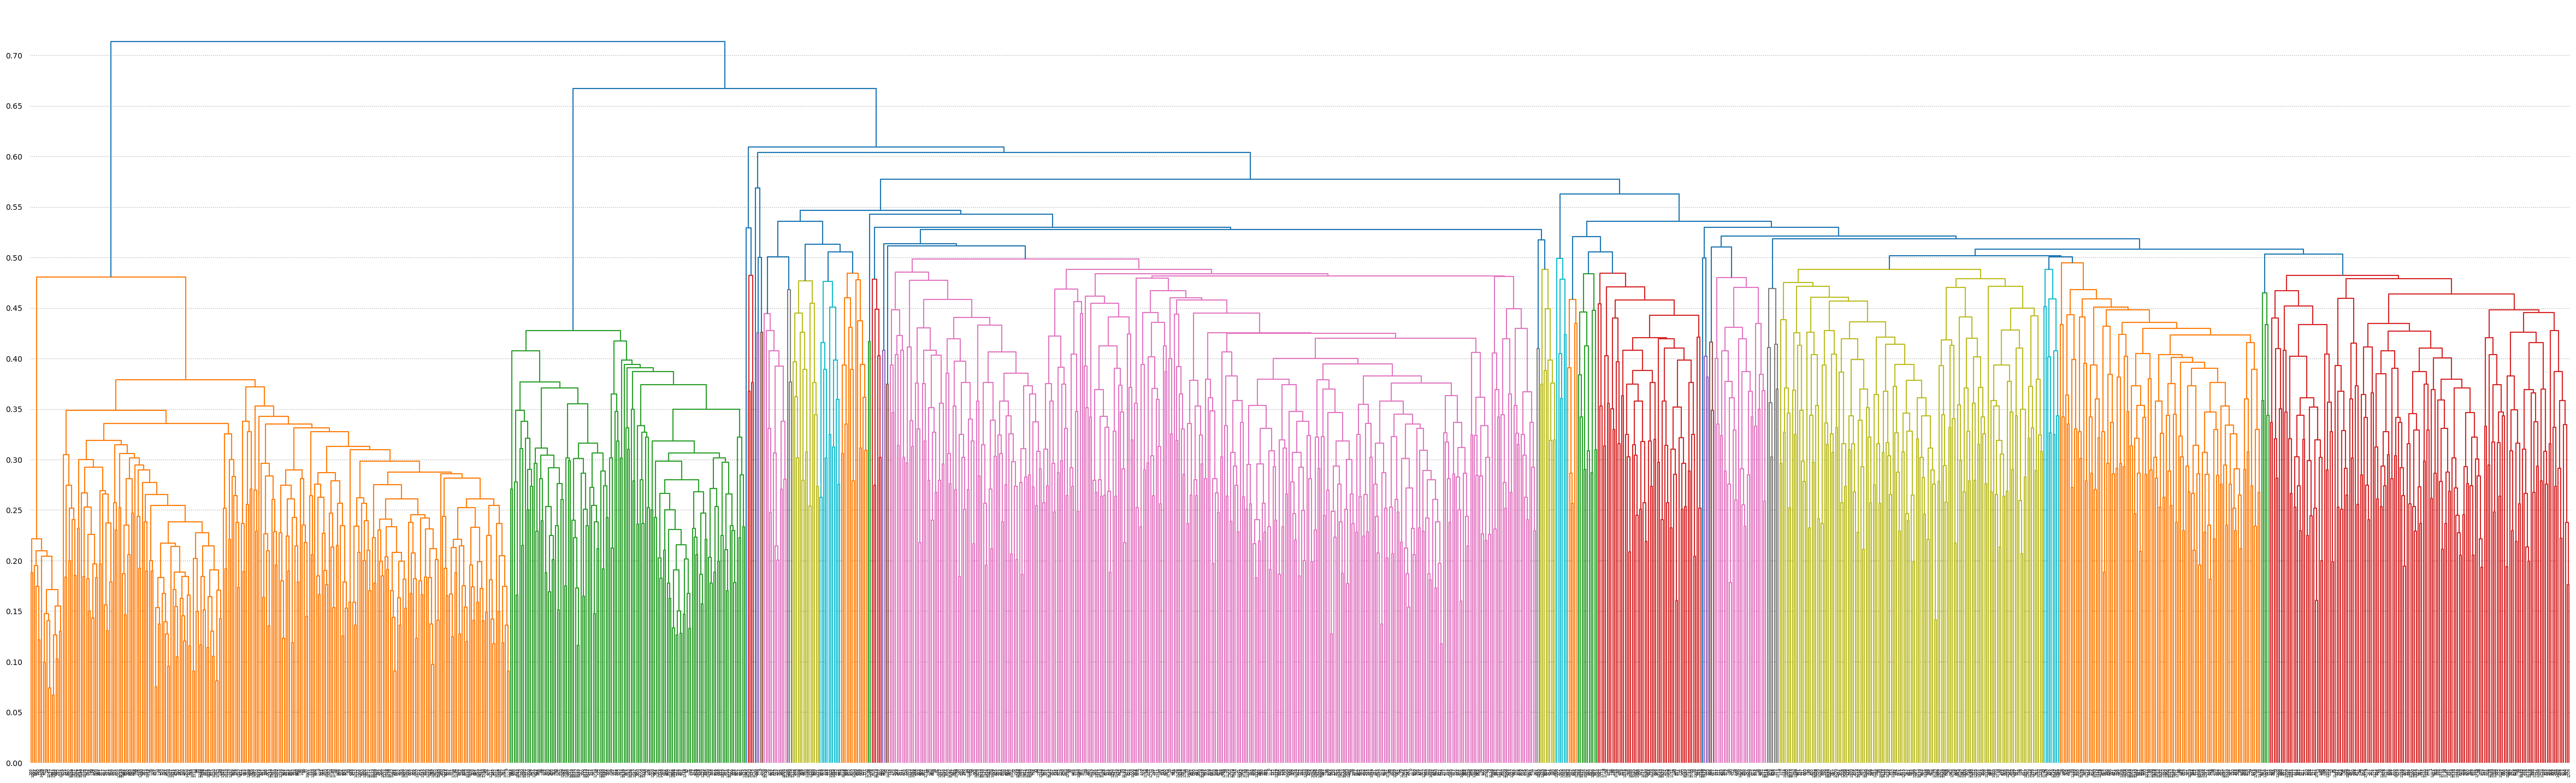

In [50]:
fig, ax = plt.subplots(figsize=(60,18))
ax.grid(True, linewidth=1, linestyle=":", axis="y")
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.tick_params(axis="y", length=0, pad=10)
ax.set_yticks(np.arange(0,1.1,.05))
plot_dendrogram(model_average, ax=ax)

In [51]:
model_average_reduced = AgglomerativeClustering(
    n_clusters=3,
    metric="precomputed",
    linkage="average",
    compute_full_tree=True,
    distance_threshold=None,
    compute_distances=True
).fit(D_reduced)

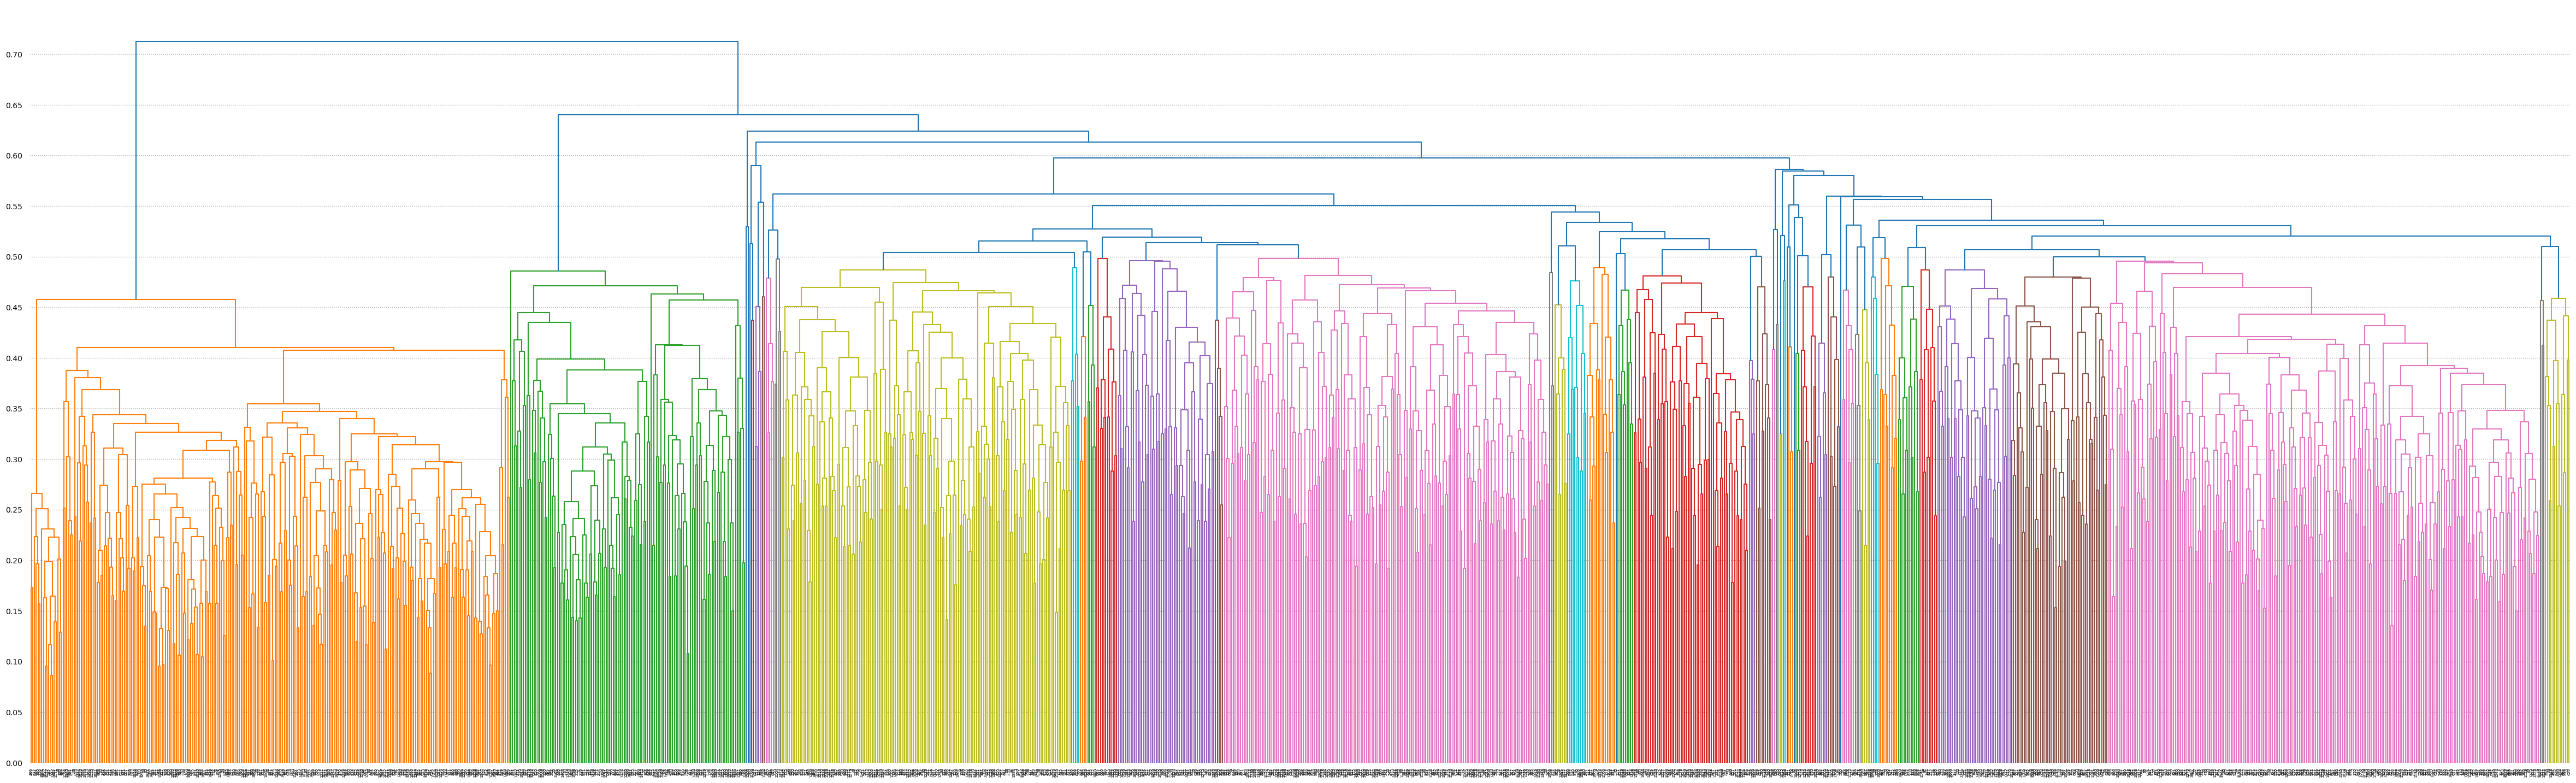

In [52]:
fig, ax = plt.subplots(figsize=(60,18))
ax.grid(True, linewidth=1, linestyle=":", axis="y")
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.tick_params(axis="y", length=0, pad=10)
ax.set_yticks(np.arange(0,1.1,.05))
plot_dendrogram(model_average_reduced, ax=ax)

In [53]:
model_single = AgglomerativeClustering(
    n_clusters=3,
    metric="precomputed",
    linkage="single",
    compute_full_tree=True,
    distance_threshold=None,
    compute_distances=True
).fit(D)

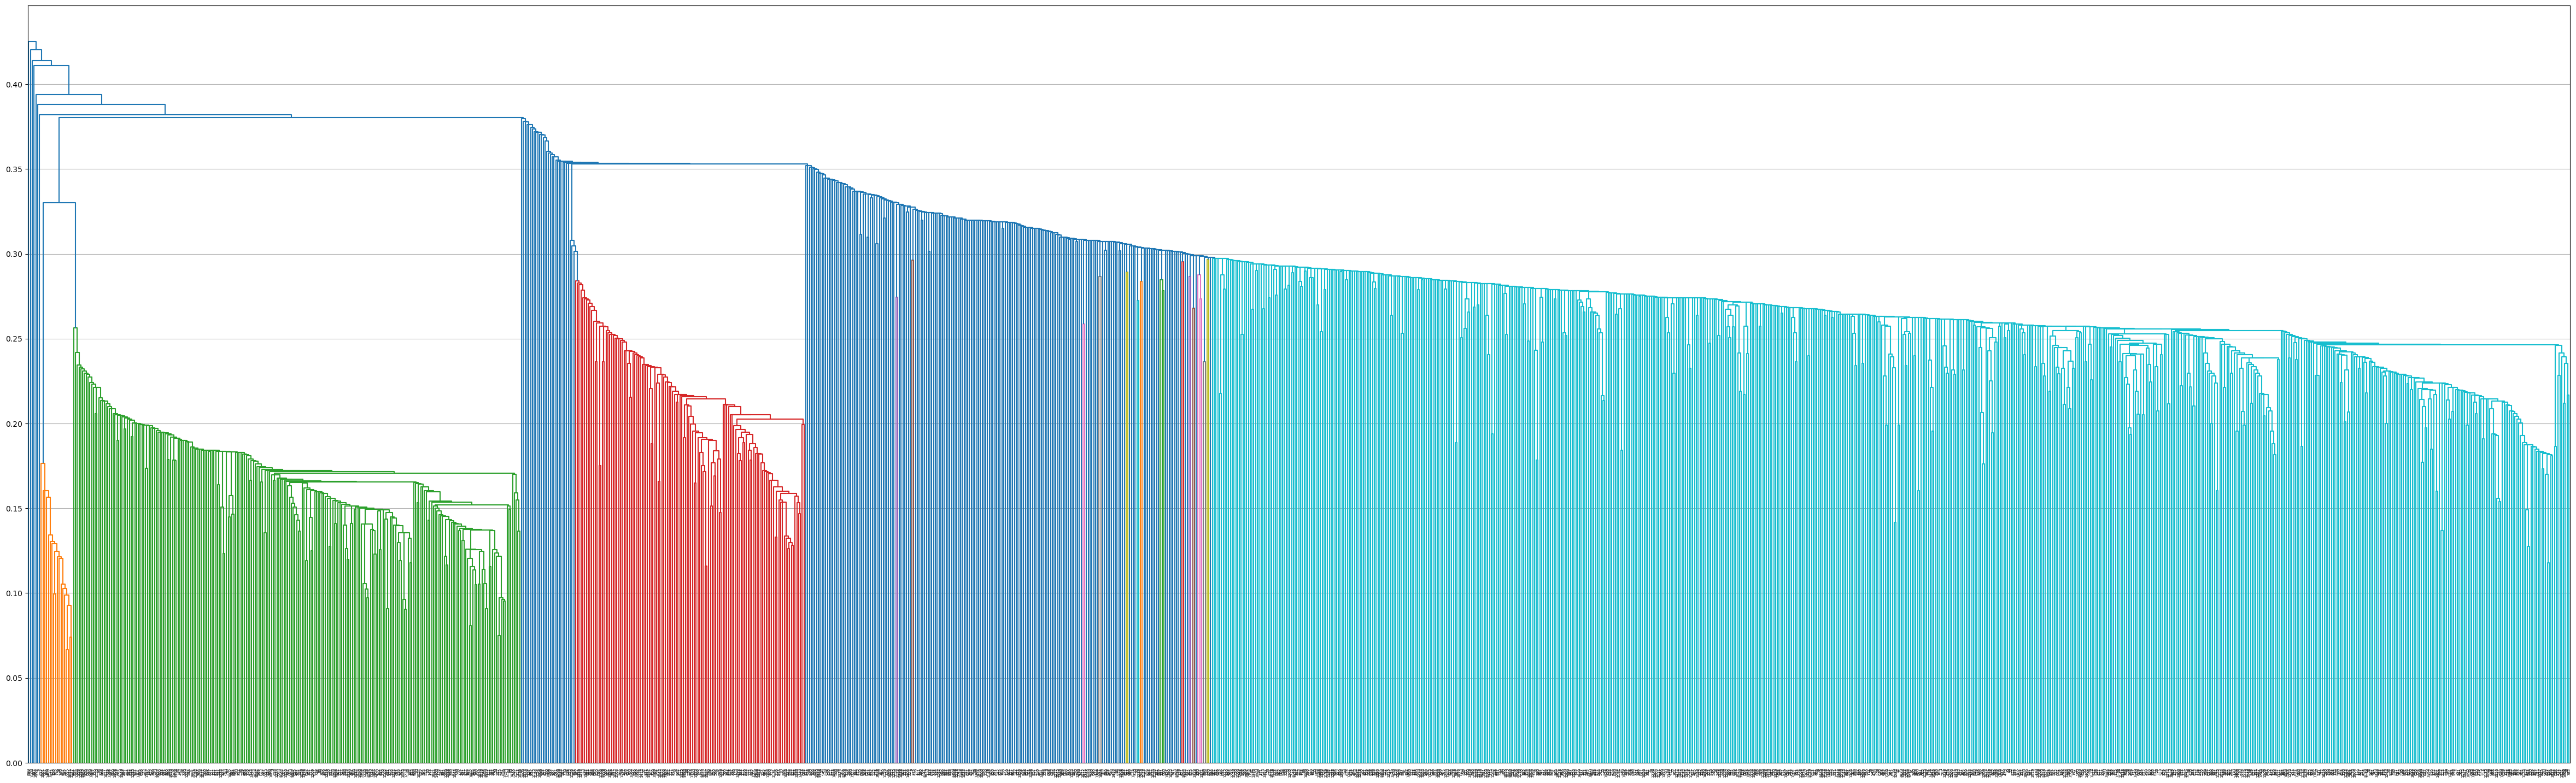

In [54]:
fig, ax = plt.subplots(figsize=(60,18))
ax.grid(True, axis="y")
ax.set_yticks(np.arange(0,1.1,.05))
plot_dendrogram(model_single, ax=ax)

In [55]:
model_single_reduced = AgglomerativeClustering(
    n_clusters=3,
    metric="precomputed",
    linkage="single",
    compute_full_tree=True,
    distance_threshold=None,
    compute_distances=True
).fit(D_reduced)

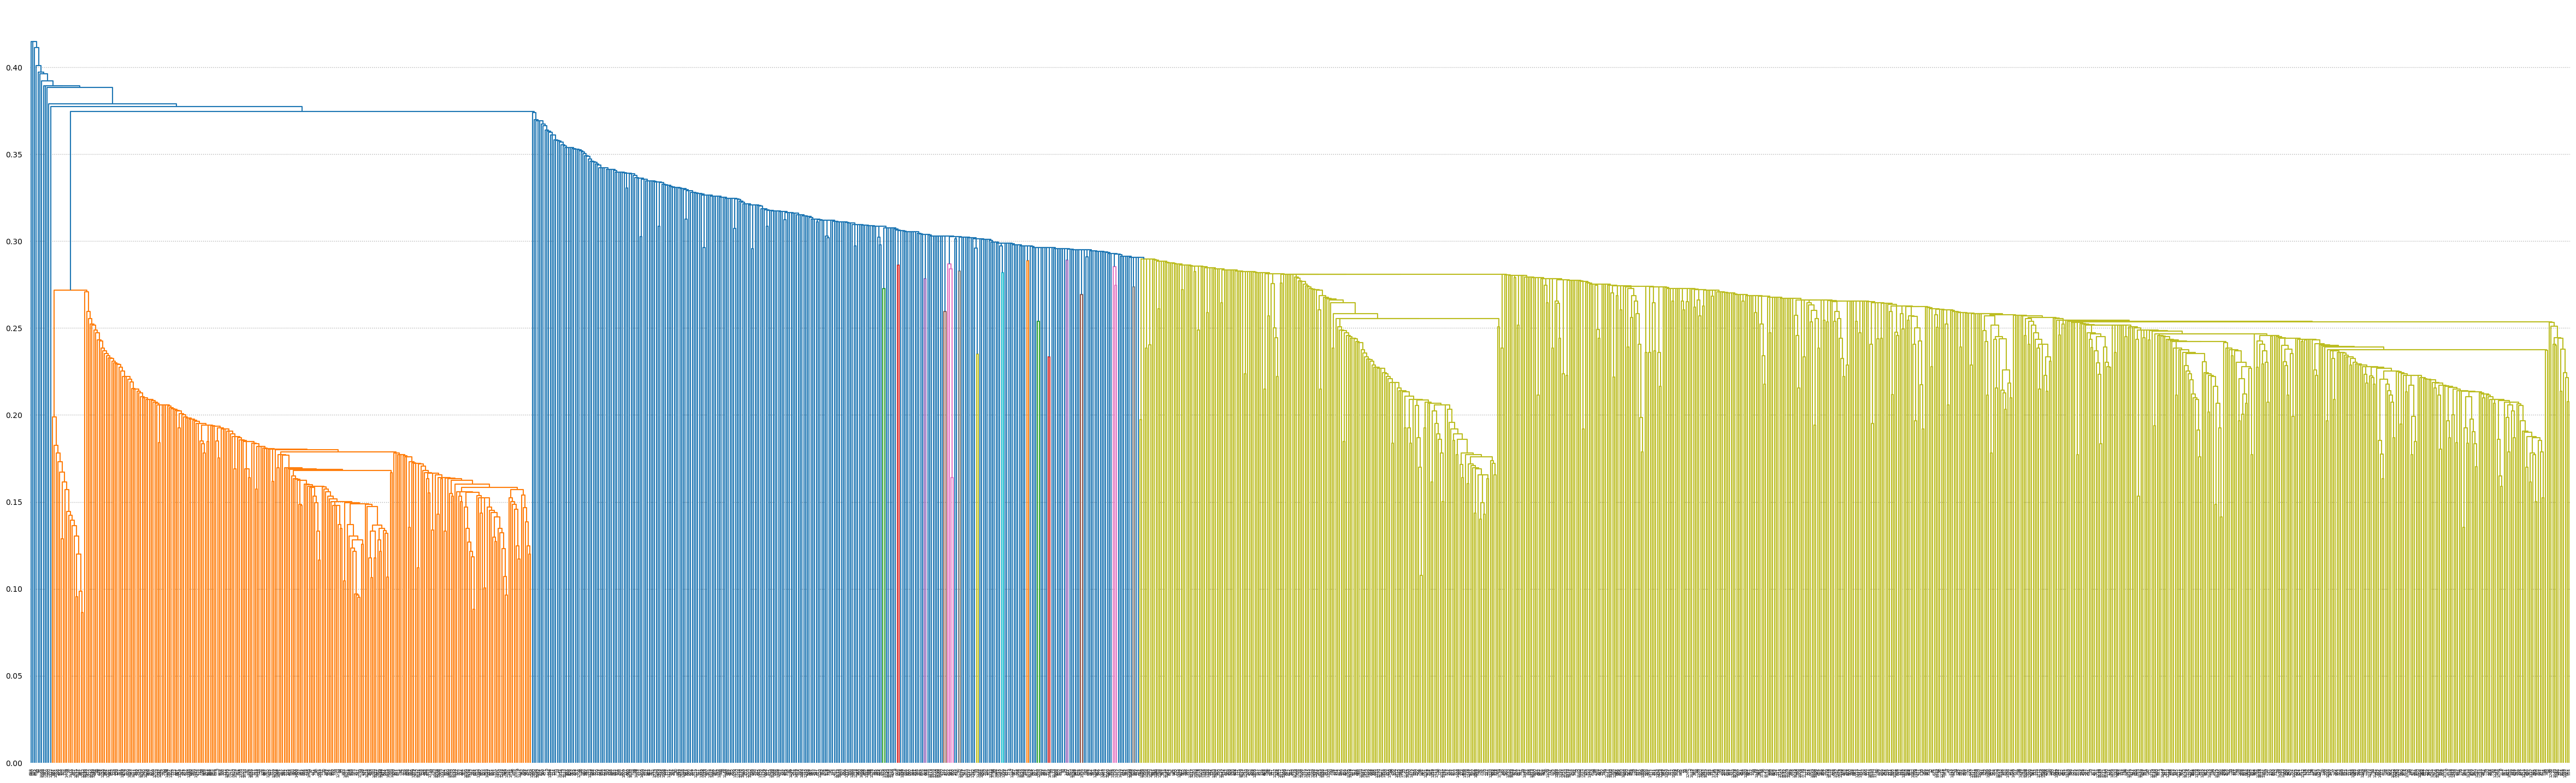

In [56]:
ig, ax = plt.subplots(figsize=(60,18))
ax.grid(True, linewidth=1, linestyle=":", axis="y")
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.tick_params(axis="y", length=0, pad=10)
ax.set_yticks(np.arange(0,1.1,.05))
plot_dendrogram(model_single_reduced, ax=ax)

### Clusters visualization

In [57]:
models = {
    "complete" : model_complete,
    "average" : model_average,
    "single" : model_single,
    "complete_reduced" : model_complete_reduced,
    "average_reduced" : model_average_reduced,
    "single_reduced" : model_single_reduced
}

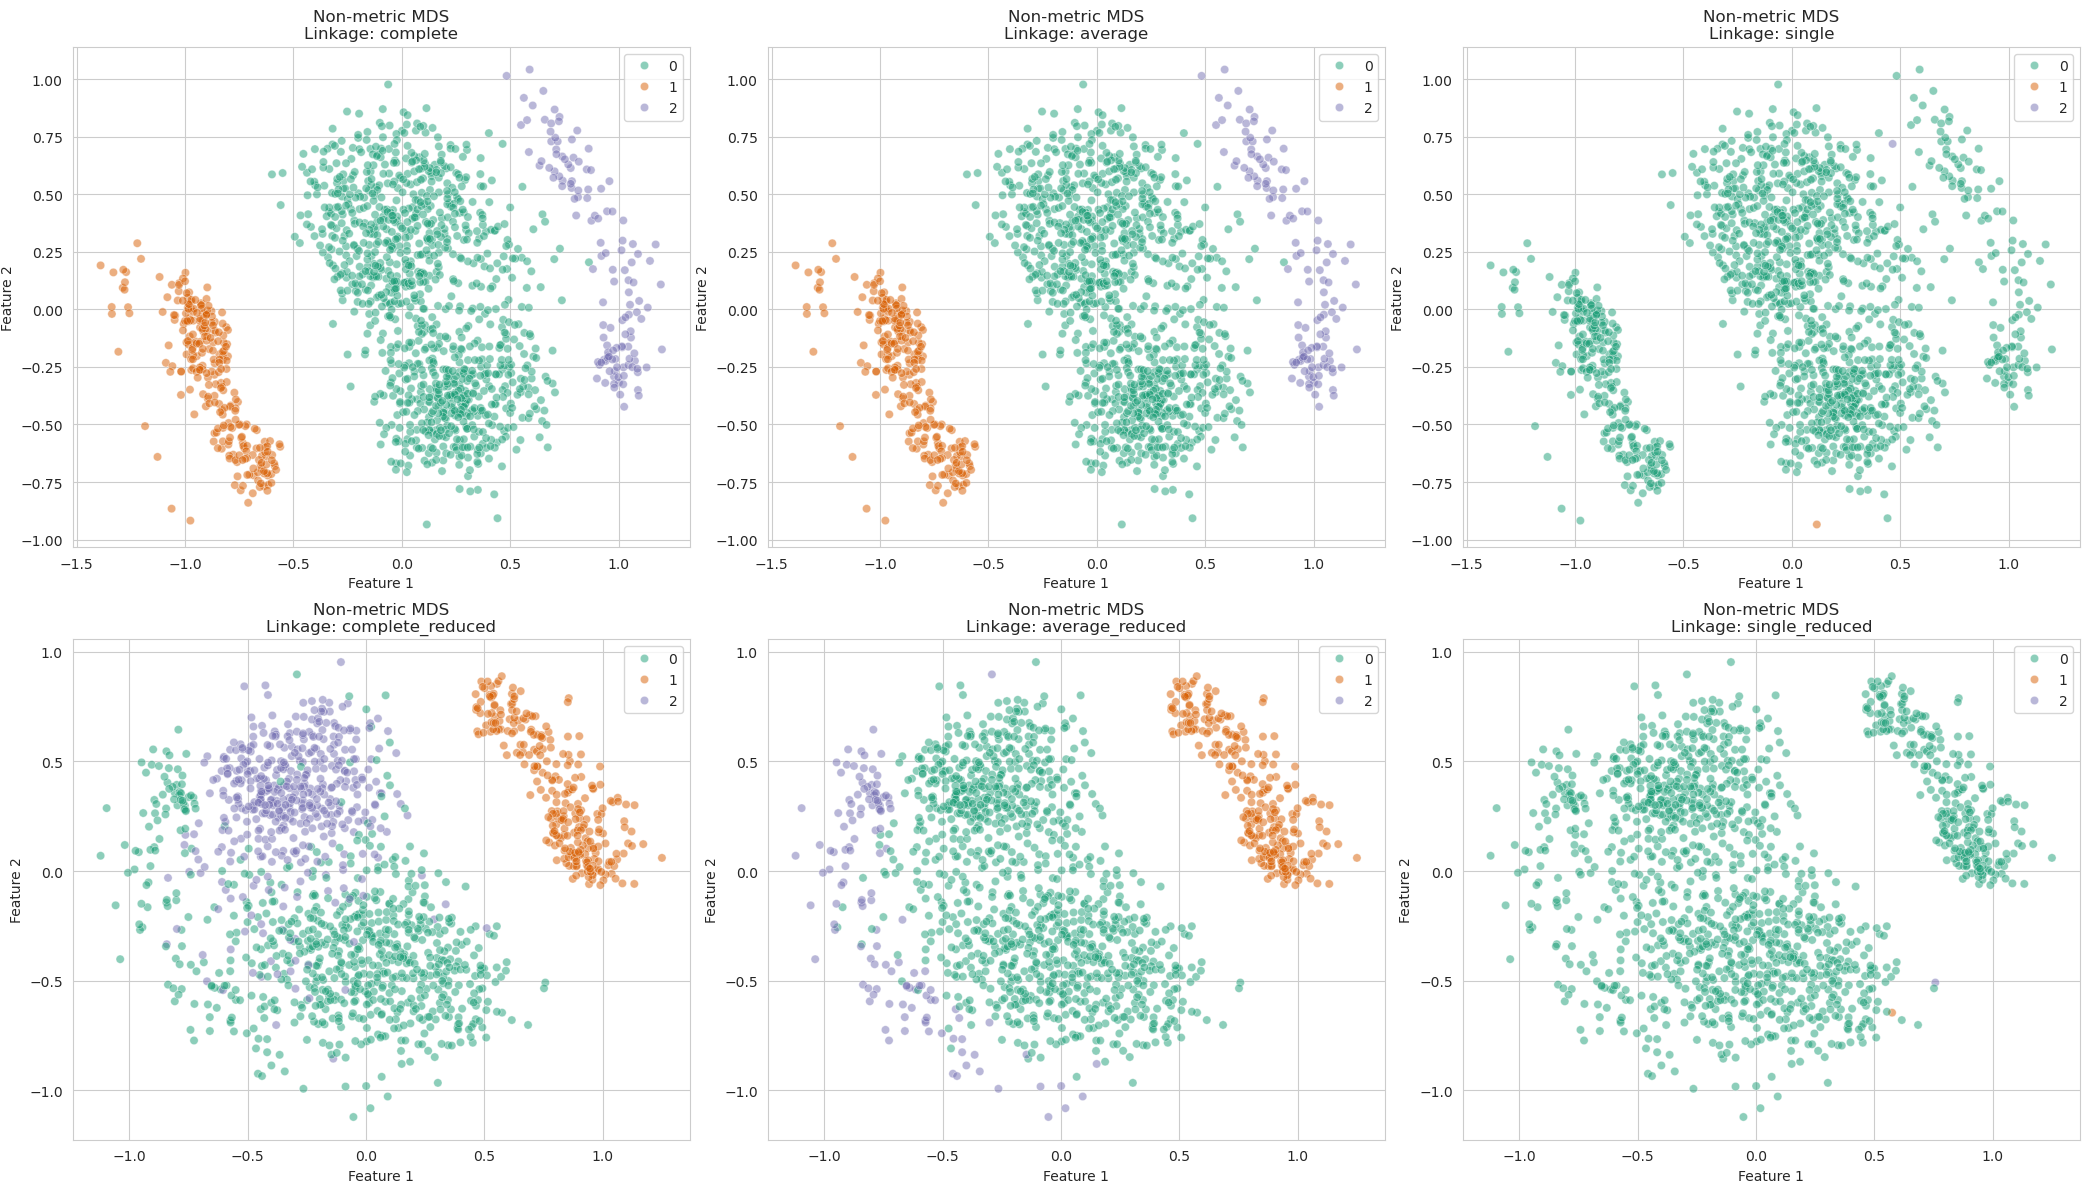

In [58]:
with sns.axes_style("whitegrid"):
    fig, axs = plt.subplots(figsize=(21,12), nrows=2, ncols=3)
    for model, ax in zip(models.keys(), axs.flatten()):
        ax.set_title(f"Non-metric MDS\nLinkage: {model}")
        ax.set_xlabel(r"Feature 1")
        ax.set_ylabel(r"Feature 2")
        if "reduced" in model:
            sns.scatterplot(x=D_transformed_reduced[:,0],
                            y=D_transformed_reduced[:,1],
                            alpha=0.5, hue=models[model].labels_,
                            palette="Dark2",
                            ax=ax)
        else:
            sns.scatterplot(x=D_transformed[:,0],
                            y=D_transformed[:,1],
                            alpha=0.5,
                            hue=models[model].labels_,
                            palette="Dark2",
                            ax=ax)
    fig.tight_layout()

### Compare clusters formed with reduced features

In [59]:
# ARI between
adjusted_rand_score(model_average.labels_, model_average_reduced.labels_)

1.0

In [60]:
adjusted_rand_score(model_complete.labels_, model_complete_reduced.labels_)

0.35989787469612916

In [61]:
cluster_results = []
cluster_results_reduced = []
for k in [2,3,4,5,6,7,8]:
    for linkage_metric in ["complete", "average"]:
        linkage_full = AgglomerativeClustering(
            n_clusters=k,
            metric="precomputed",
            linkage=linkage_metric,
            compute_full_tree=True,
            distance_threshold=None,
            compute_distances=True
        ).fit(D)
        
        cluster_results.append(linkage_full)
        
        linkage_reduced = AgglomerativeClustering(
            n_clusters=k,
            metric="precomputed",
            linkage=linkage_metric,
            compute_full_tree=True,
            distance_threshold=None,
            compute_distances=True
        ).fit(D_reduced)

        cluster_results_reduced.append(linkage_reduced)

In [62]:
for full, reduced in zip(cluster_results, cluster_results_reduced):
    print(f"Linkage:\nFull features: {full.linkage}; n_clusters: {full.n_clusters}\nReduced features: {reduced.linkage}; n_clusters {reduced.n_clusters}")
    print(f"ARI: {adjusted_rand_score(full.labels_, reduced.labels_)}")
    print()

Linkage:
Full features: complete; n_clusters: 2
Reduced features: complete; n_clusters 2
ARI: 1.0

Linkage:
Full features: average; n_clusters: 2
Reduced features: average; n_clusters 2
ARI: 1.0

Linkage:
Full features: complete; n_clusters: 3
Reduced features: complete; n_clusters 3
ARI: 0.35989787469612916

Linkage:
Full features: average; n_clusters: 3
Reduced features: average; n_clusters 3
ARI: 1.0

Linkage:
Full features: complete; n_clusters: 4
Reduced features: complete; n_clusters 4
ARI: 0.33115757355088127

Linkage:
Full features: average; n_clusters: 4
Reduced features: average; n_clusters 4
ARI: 0.9856712899851738

Linkage:
Full features: complete; n_clusters: 5
Reduced features: complete; n_clusters 5
ARI: 0.5010558815070929

Linkage:
Full features: average; n_clusters: 5
Reduced features: average; n_clusters 5
ARI: 0.9656119752835739

Linkage:
Full features: complete; n_clusters: 6
Reduced features: complete; n_clusters 6
ARI: 0.45573923167077235

Linkage:
Full features: 

In [63]:
final_clusters = cluster_results[3]

In [64]:
silhouette_scores_average = []
silhouette_scores_complete = []
for linkage in cluster_results:
    if linkage.linkage == "average":
        score = silhouette_score(D, linkage.labels_, metric="precomputed")
        silhouette_scores_average.append(score)
    elif linkage.linkage == "complete":
        score = silhouette_score(D, linkage.labels_, metric="precomputed")
        silhouette_scores_complete.append(score)

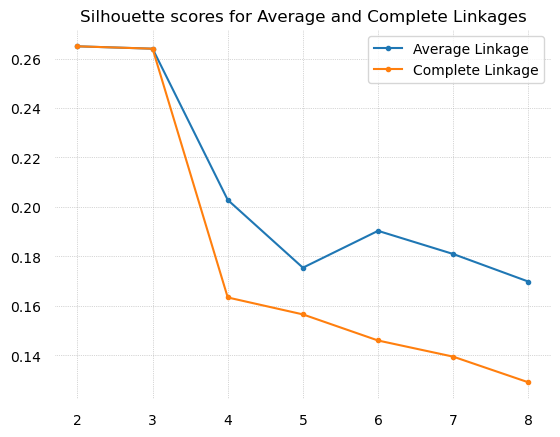

In [65]:
fig, ax = plt.subplots()
ax.plot(
    np.arange(2,9,1),
    silhouette_scores_average,
    marker='.',
    label="Average Linkage"
)
ax.plot(
    np.arange(2,9,1),
    silhouette_scores_complete,
    marker='.',
    label="Complete Linkage"
)
ax.legend(loc="upper right")
ax.set_title("Silhouette scores for Average and Complete Linkages")
ax.grid(True, linestyle=":", linewidth=0.5)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.tick_params(axis="both", length=0, pad=10)

### Final Visualization

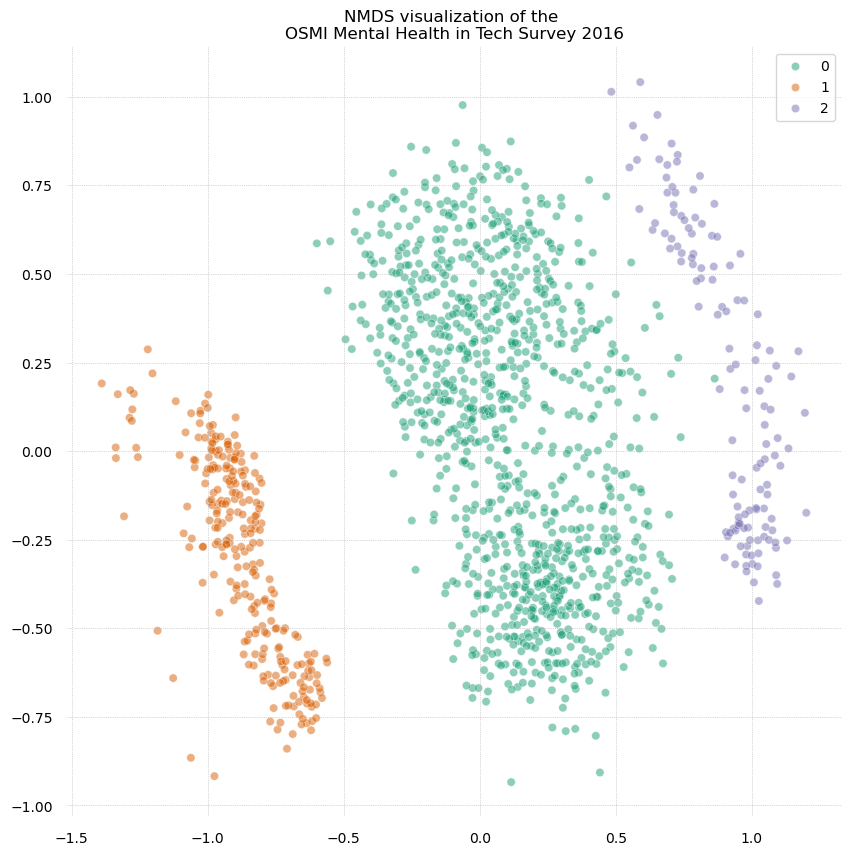

In [66]:
fig, ax = plt.subplots(figsize=(10,10))
sns.scatterplot(
    x=D_transformed[:,0],
    y=D_transformed[:,1],
    alpha=0.5,
    hue=final_clusters.labels_,
    palette="Dark2",
    ax=ax)

ax.set_title("NMDS visualization of the \nOSMI Mental Health in Tech Survey 2016")
ax.grid(True, linestyle=":", linewidth=0.5)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.tick_params(axis="both", length=0, pad=10)

## Describing the clusters

In [67]:
df_cluster = df.copy()

In [69]:
df_cluster["cluster"] = final_clusters.labels_

In [70]:
df_cluster["cluster"].value_counts(normalize=True)

cluster
0    0.718330
1    0.188960
2    0.092711
Name: proportion, dtype: float64

In [71]:
def cluster_profile(question, df):
    return (
        df.groupby("cluster")[question]
        .value_counts(normalize=True)
        .rename("proportion")
        .reset_index()
    )

### Observations
- Cluster 1 contains all self-employed worker and cluster 0 and 2 all salary workers.
- Most workers in cluster 0 work for a company with 26-100 employees 25.7%, Most workers in cluster 2 work for companies with more than 1000 people 29%
- Most workers in cluster 0 and 2 work for tech companies (77% and 72%, respectively)
- Most employers of cluster 0 provide mental health benefits with 47.2%, employers in cluster 2 provide less benefits with 38%.  
  For both, clusters 0 and 2 around 27% of people are not aware of the benefits.
- For cluster 0, 70.4% of employers have not discussed mental health as part of a wellness campaign, for cluster 2, 74% also have not.
- For cluster 0, only 26% of employers offer resources to learn about mental health and 28% of people do not know it.  
  For cluster 2, 22% offer the resources and 24% of people do not know.
- It is easier for the majority people in cluster 2 to ask for leave in case of mental issue than for people in cluster 0.
- More people in cluster 2 believe that discussing mental health issues with their emplyer would have negative consequences than in cluster 0. Around the same people are unsure about it.
- Discussing physical health with the employers seems to be less difficult.
- Most people in cluster 0 would be or maybe willing to discuss mental health issues with coworkers while people in cluster 2 are more reserved. In cluster 2 40% of people say they would not do it while in cluster 0 only 33% would not.
- 40% of workrs in cluster 2 would not feel comfortable discussing mental health with their supervisor, while in cluster 0 only 27% of worker would not feel comfortable
- Around 74% of workers in cluster 2 do not believe or are unsure whether their employer takes mental healt as seriously as physical healt, while in cluster 0, it is 68% of worker who feel this way
- Cluster 0 includes workers that have had previous employers while cluster 2 includes only workers without previous employers
- For both cluster 0 and 1, for the majority of workers, previous employers did not formally discuss mental health (67% and 77%).  
  For cluster 0, 22.5% of workers said their employers did discuss mental health compared to only 9% in cluster 1
- 31% of workers in cluster 0 stated that some of their previous employers provided resources to leran about mental health, while for cluster 1, only 18% that some of their empployers did so
- For both clusters 0 and 1, around 70% of employers do not know if theis anonimity was protected if they chose to take advantage of treatment resources
- 33% of workers in cluster 0 stated that some of their coworkers with mental health issues experiences negative consequences in previous work places, in cluster 1 40% observed negative consequences for their previous co-workers
- Across all clusters, more than half of the workers said they would not bring up a mental health issue with a potential employer during an interview.
- Across all clusters, workers feel that being identifies as a person with a mental health issue would hurt their carreer
- 48% of worker in cluster 0 have a familiy history of mental illness, 45% in cluster 1 and 33% for cluster 2
- 52% of worker in cluster 0 have had a mental disorder in the past, 55% in cluster 1 and 39% in cluster 2
- At leat half of workers in cluster 0 and 1 have been diagnosed with a mental disorder by a healt professional while in cluster 2 only 39% have been diagnosed
- Consequently most people in cluster 0 and 1 have sought out treatment
- Gender distribution across cluster is comparable
- Most workers in cluster 0 and 2 are back-end and front-end developers, while in cluster 1 most are a "one person shop", they do a bit of everything
- 25% of peopls in cluster 0 never work remotely, 5% people in cluster 1 never work remotely, 42% in cluster 2 never work remotely. Around 50% of people in all cluster work remotely sometimes.
- Mean age in cluster 1 is 36 years old, cluster 0 33 years old and cluster 2 29. All ages seem to be equally distributed across clusters. T-test necessary to see if disfference is significant

### Cluster characteristics

General notes

1. The clusters are mostly distinguished by whether someon is self-employed or not, or whether they have had previous employers.  
   Many questions in the survey reflect this and it can be appreciated in the NMDS visualization.
2. No difference between clusters regarding age.
3. No difference between cluster regarding gender.

Cluster 0

1. People with longer careers, they have had at least one previous employer.
2. More experience with employers discussin mental health.
3. People with mental health issues in familiy history and also more diagnosis.
4. Mostly workers in exclusively tech roles
5. No strong tendency to work remotely

Cluster 1

1. Formed by both, people with previuos employers and people with no previous employers.
2. Only a few people have had experience with their previous emplyers discussing mental health.
3. People with mental health issues in familiy history and also more diagnosis.
4. "One person shops"
5. More likely to work remotely

Cluster 2

1. More afraid of possible consequences when discussin mental health.
2. More reluctant to openly discuss mental health issues.
3. Less trust in their employers, when it comes to the employers taking mental health seriuosly.
4. People in their early career, they haven't had any previous employers.
5. People with less history of mental illness and less diagnosis.
6. Mostly workers with exclusively tech roles
7. Less likely to work remotely

In [81]:
for question in df_cluster.columns:
    if question == "cluster":
        continue
    elif question == "What is your age?":
        display(df_cluster.groupby("cluster")[question].describe().reset_index())
    else:
        profile = cluster_profile(question, df_cluster)
        display(profile)

,cluster,Are you self-employed?,proportion
0,0,0,1.0
1,1,1,1.0
2,2,0,1.0


,cluster,How many employees does your company or organization have?,proportion
0,0,26-100,0.257143
1,0,100-500,0.224631
2,0,More than 1000,0.214778
3,0,6-25,0.181281
4,0,500-1000,0.071921
5,0,1-5,0.050246
6,1,Not applicable,1.000000
7,2,More than 1000,0.290076
8,2,26-100,0.236641
9,2,6-25,0.198473


,cluster,Is your employer primarily a tech company/organization?,proportion
0,0,1.0,0.776355
1,0,0.0,0.223645
2,1,2.0,1.000000
3,2,1.0,0.725191
4,2,0.0,0.274809


,cluster,Does your employer provide mental health benefits as part of healthcare coverage?,proportion
0,0,Yes,0.472906
1,0,I don't know,0.278818
2,0,No,0.182266
3,0,Not eligible for coverage / N/A,0.066010
4,1,Not applicable,1.000000
5,2,Yes,0.389313
6,2,I don't know,0.274809
7,2,No,0.213740
8,2,Not eligible for coverage / N/A,0.122137


,cluster,Do you know the options for mental health care available under your employer-provided coverage?,proportion
0,0,No,0.306404
1,0,I am not sure,0.303448
2,0,Yes,0.274877
3,0,unknown,0.115271
4,1,unknown,1.000000
5,2,I am not sure,0.335878
6,2,No,0.328244
7,2,Yes,0.213740
8,2,unknown,0.122137


...

,cluster,"If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",proportion
0,0,Often,0.372414
1,0,Not applicable to me,0.326108
2,0,Sometimes,0.255172
3,0,Rarely,0.037438
4,0,Never,0.008867
5,1,Often,0.423221
6,1,Not applicable to me,0.284644
7,1,Sometimes,0.254682
8,1,Rarely,0.029963
9,1,Never,0.007491


,cluster,count,mean,std,min,25%,50%,75%,max
0,0,1015.0,33.476847,6.776890,17.0,29.0,33.0,38.0,55.0
1,1,267.0,36.232210,7.872003,19.0,31.0,35.0,41.5,55.0
2,2,131.0,29.519084,7.807640,20.0,24.0,27.0,33.0,55.0


,cluster,What is your gender?,proportion
0,0,male,0.737931
1,0,female,0.237438
2,0,non-binary,0.024631
3,1,male,0.722846
4,1,female,0.258427
5,1,non-binary,0.018727
6,2,male,0.763359
7,2,female,0.198473
8,2,non-binary,0.038168


,cluster,Which of the following best describes your work position?,proportion
0,0,Back-end Developer,0.277833
1,0,Front-end Developer,0.168473
2,0,Supervisor/Team Lead,0.150739
3,0,Other,0.123153
4,0,DevOps/SysAdmin,0.105419
5,0,Support,0.050246
6,0,Executive Leadership,0.045320
7,0,Dev Evangelist/Advocate,0.044335
8,0,Designer,0.022660
9,0,One-person shop,0.004926


,cluster,Do you work remotely?,proportion
0,0,Sometimes,0.534975
1,0,Never,0.258128
2,0,Always,0.206897
3,1,Sometimes,0.494382
4,1,Always,0.453184
5,1,Never,0.052434
6,2,Sometimes,0.519084
7,2,Never,0.427481
8,2,Always,0.053435


In [ ]:
results_independence_clusters = []
for question in df_cluster.columns:
    if question == "cluster" or question == "What is your age?":
        continue
    contingency_table = pd.crosstab(df_cluster["cluster"], df_cluster[question])
    chi2, pvalue, _, _ = chi2_contingency(contingency_table)
    v = association(contingency_table, method="cramer")

    result_independence = {
        "question" : question,
        "p_value" : pvalue,
        "chi2" : chi2,
        "cramers_v" : v
    }
    results_independence_clusters.append(result_independence)

results_independence = pd.DataFrame(results_independence_clusters)
results_independence = results_independence.sort_values(by="p_value", ascending=True)

reject, pvalue_corrected, _, _ = multipletests(
    results_independence["p_value"].values,
    alpha=0.05,
    method="fdr_bh"
)

results_independence["reject_h0"] = reject
results_independence["p_value_corrected"] = pvalue_corrected

In [111]:
print(results_independence)

,question,p_value,chi2,cramers_v,reject_h0,p_value_corrected
0,Are you self-employed?,1.482342e-307,1413.000000,1.000000,True,6.374072e-306
12,Would you feel comfortable discussing a mental...,1.460567e-306,1433.342182,0.712179,True,3.140220e-305
2,Is your employer primarily a tech company/orga...,3.642885e-305,1415.117821,0.707636,True,5.221468e-304
14,Have you heard of or observed negative consequ...,1.004457e-304,1413.086439,0.707128,True,1.011769e-303
7,Is your anonymity protected if you choose to t...,1.176476e-304,1424.539840,0.709988,True,1.011769e-303
9,Do you think that discussing a mental health d...,1.928333e-303,1418.930645,0.708589,True,1.381972e-302
11,Would you feel comfortable discussing a mental...,2.725525e-303,1418.236680,0.708416,True,1.610654e-302
13,Do you feel that your employer takes mental he...,2.996565e-303,1418.046533,0.708368,True,1.610654e-302
6,Does your employer offer resources to learn mo...,5.856635e-303,1416.702529,0.708033,True,2.798170e-302
5,Has your employer ever formally discussed ment...,1.265813e-302,1415.156718,0.707646,True,5.442998e-302


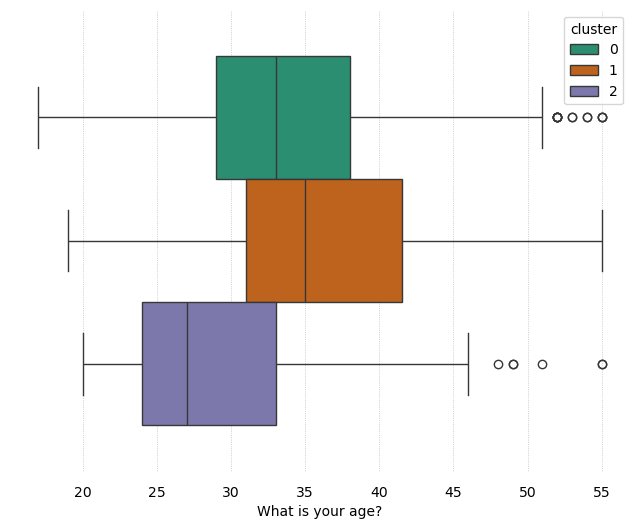

In [117]:
fig, ax = plt.subplots(figsize=(8,6))
sns.boxplot(
    df_cluster,
    x="What is your age?",
    hue="cluster",
    palette="Dark2",
    ax=ax
)
ax.grid(True, linestyle=":", linewidth=0.5, axis="x")
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.tick_params(axis="both", length=0, pad=10)